<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_TP2/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_2%2C_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 — Análisis Exploratorio de Datos



---
**Dataset:** `propiedades.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta Axel, Bareiro Santiago, Borges Agustin  
**Fecha:** xx/03/2026

---
#Configuracion del entorno

In [2]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

# Detectar Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Ejecución en Google Colab. Clonando repositorio...")
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", "https://github.com/AxelSkrauba/applied-ai-engineering.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

# Importar utilidades globales
from utils.plots import setup_plot_style
setup_plot_style()

Ejecución en Google Colab. Clonando repositorio...


In [3]:
# Importación de librerías específicas para este notebook
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore') # Mantenemos los logs limpios

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Esta función engloba código reutilizable para la gestión y carga de los datos
from utils.data import load_dataset

dataset_path = "/content/drive/MyDrive/datasets/propiedades/propiedades.csv"
datasetPropiedades = pd.read_csv(dataset_path)
dataset_path = "/content/drive/MyDrive/datasets/churn/clientes_churn.csv"
datasetChurn = pd.read_csv(dataset_path)
dataset_path = "/content/drive/MyDrive/datasets/desconocido/dataset_desconocido.csv"
datasetDesconocido = pd.read_csv(dataset_path)


---
#Ejercicio 1: Comprensión inicial de datos reales


---

## 1.1 Carga y primera inspección

In [6]:
print("Primeras 10 filas del dataset:\n")
datasetPropiedades.head(10)

Primeras 10 filas del dataset:



,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,648900.0,232.9,6,5.0,Palermo,2786.17
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59
5,6,301300.0,100.6,3,29.0,Recoleta,2995.03
6,7,161000.0,49.3,2,1.0,Palermo,3265.72
7,8,309100.0,112.0,5,50.0,Palermo,2759.82
8,9,175500.0,93.0,2,27.0,Centro,1887.10
9,10,43200.0,44.0,2,41.0,Sur,981.82


Cada **fila** representa un registro histórico único de una propiedad inmobiliaria particular puesta a la venta en la región.

Cada **columna** representa una característica o atributo específico de esa propiedad (como el precio de venta o superficie total por ejemplo). La columna `id` es simplemente un identificador único para cada registro.

Los tipos de variables presentes son los siguientes:

*   `id`: Identificador único.
*   `precio`, `superficie_m2`, `precio_m2`, `antiguedad_años`: variables numericas continuas.
*   `habitaciones`: variable numerica discreta.
*   `barrio`: variable categórica.




In [7]:
# Resumen de los tipos de datos y recuento de valores no nulos
datasetPropiedades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               800 non-null    int64  
 1   precio           768 non-null    float64
 2   superficie_m2    800 non-null    float64
 3   habitaciones     800 non-null    int64  
 4   antiguedad_años  752 non-null    float64
 5   barrio           800 non-null    object 
 6   precio_m2        768 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 43.9+ KB


Haciendo uso del metodo `.info()` se evidencian 800 instancias (`entries`, filas) y 7 variables (columnas).

En el contexto de un Análisis Explotariorio de Datos (EDA) inicial para un mercado inmobiliario regional, 800 observaciones es un volumen estadísticamente decente. Esta cantidad nos permite realizar agrupaciones decente. Esta cantidad nos permite realizar agrupaciones, calcular medidas de tendencia central, de dispersión de confianza, y construir una intuición analítica sólida sin que valores extremos (outliers) distorsiones fuertemente las conclusiones generales.

Tambien, podemos apreciar que no todas las variables tienen un tipo de dato adecuado del todo. Si bien las variables continuas (`precio`, `superficie_m2`, `precio_m2`) y categóricas (`barrio`) tienen tipos de datos computacionales correctos (float64 y object), se detectó una discrepancia en la variable `antiguedad_años`.

Desde la teoría estadística, la antigúedad en años es una variable **numérica discreta**, por lo que su tipo computacional ideal debería ser entero (`int64`). Sin embargo, el método `.info()` revela que está cargada como `float64`.

Nuestra hipótesis es que esta anomalía se debe a la presencia de valores nulos en dicha columna (solo posee 752 valores no nulos sobre 800). En la arquitectura de Pandas, la inclusión de valores `NaN` fuerza a que toda columna convierta a punto flotante. para corregir este tipo de dato, primero se deberá tomar una decisión sobre cómo tratar o imputar estos valores faltantes en la etapa de Calidad de Datos.


---
## 1.2 Calidad de los datos

###1.2.1 Valores Faltantes

In [8]:
faltantes = datasetPropiedades.isnull().sum()
pct_faltantes = (faltantes / len(datasetPropiedades) * 100).round(2)

resumen_faltantes = pd.DataFrame({
    "Cantidad": faltantes,
    "Porcentaje (%)": pct_faltantes
}).query("Cantidad > 0")

print("Variables con valores faltantes:")
print(resumen_faltantes)


Variables con valores faltantes:
                 Cantidad  Porcentaje (%)
precio                 32             4.0
antiguedad_años        48             6.0
precio_m2              32             4.0



Existen valores nulos en dos variables:
- `precio`: **32 valores faltantes (4%)**.
- `antiguedad_años`: **48 valores faltantes (6%)**.
- `precio_m2` hereda los faltantes de `precio` por ser una variable derivada.

###1.2.2 Detección de valores inconsistentes o erróneos

Ahora vamos a verificar si existen valores negativos en las columnas numéricas que no deberían tenerlos, como `precio`, `superficie_m2`, `precio_m2`, `habitaciones` y `antiguedad_años`.

In [9]:
columnas_numericas = ['precio', 'superficie_m2', 'precio_m2', 'antiguedad_años', 'habitaciones']

for col in columnas_numericas:
    if col in datasetPropiedades.columns:
        valores_negativos = datasetPropiedades[datasetPropiedades[col] < 0]
        if not valores_negativos.empty:
            print(f"Se encontraron valores negativos en la columna '{col}':")
            display(valores_negativos)
        else:
            print(f"No se encontraron valores negativos en la columna '{col}'.")
    else:
        print(f"La columna '{col}' no existe en el dataset.")

No se encontraron valores negativos en la columna 'precio'.
No se encontraron valores negativos en la columna 'superficie_m2'.
No se encontraron valores negativos en la columna 'precio_m2'.
No se encontraron valores negativos en la columna 'antiguedad_años'.
No se encontraron valores negativos en la columna 'habitaciones'.


###1.2.3 Decisiones a tomar frente a valores faltantes

Los modelos de ML matemáticos no saben cómo lidiar con un valor vacío (`NaN` o `Null`). Debemos identificarlos y tomar decisiones informadas sobre qué hacer con ellos.

Para variables numéricas, si son pocas las faltantes se suele **imputar** (rellenar) con la mediana.
Si es categorica y faltan muchos datos se puede imputar con la moda pero se sesgaria mucho los datos, o se puede eliminar las filas con esta información.

Si los valores faltantes son muchos para un tipo de dato no conviene eliminar, si el dato es numerico se puede imputar usando el promedio con los datos que no faltan
Si hay datos atípicos (outliers), en ese caso es mejor utilizar la mediana.
Se puede ignorar algunos datos dependiendo de la lógica, si el dato es piscina y falta el dato que indique si posee o no, indica que no posee, y que no se decidió anotar.


In [10]:
print('Valores faltantes antes de la imputación:')
display(datasetPropiedades.isnull().sum())

# Imputar valores faltantes en 'precio' con la mediana
median_precio = datasetPropiedades['precio'].median()
datasetPropiedades['precio'].fillna(median_precio, inplace=True)
print(f"'precio' imputado con la mediana: {median_precio:.2f}")

# Imputar valores faltantes en 'antiguedad_años' con la mediana
median_antiguedad = datasetPropiedades['antiguedad_años'].median()
datasetPropiedades['antiguedad_años'].fillna(median_antiguedad, inplace=True)
print(f"'antiguedad_años' imputado con la mediana: {median_antiguedad:.2f}")

# Imputar valores faltantes en 'precio_m2' con la mediana
median_precio_m2 = datasetPropiedades['precio_m2'].median()
datasetPropiedades['precio_m2'].fillna(median_precio_m2, inplace=True)
print(f"'precio_m2' imputado con la mediana: {median_precio_m2:.2f}")

print('\nValores faltantes después de la imputación:')
display(datasetPropiedades.isnull().sum())

Valores faltantes antes de la imputación:


,0
id,0
precio,32
superficie_m2,0
habitaciones,0
antiguedad_años,48
barrio,0
precio_m2,32


'precio' imputado con la mediana: 160000.00
'antiguedad_años' imputado con la mediana: 18.00
'precio_m2' imputado con la mediana: 1841.94

Valores faltantes después de la imputación:


,0
id,0
precio,0
superficie_m2,0
habitaciones,0
antiguedad_años,0
barrio,0
precio_m2,0


---
## 1.3 Estadística Descriptiva

### 1.3.1 Alta variabilidad entre datos



In [14]:
columnas_numericas = datasetPropiedades.select_dtypes(include=['number']).columns

# Calcular la media y la desviación estándar para cada columna numérica
valores_media = datasetPropiedades[columnas_numericas].mean()
valores_desviacion = datasetPropiedades[columnas_numericas].std()

# CV = Desviación Estándar / Media
cv = (valores_desviacion / valores_media)

# Crear un DataFrame para mostrar los resultados de manera ordenada
cv_df = pd.DataFrame({
    'Media': valores_media,
    'Desviación Estándar': valores_desviacion,
    'Coeficiente de Variación': cv
}).sort_values(by='Coeficiente de Variación', ascending=False)

display(cv_df)

,Media,Desviación Estándar,Coeficiente de Variación
superficie_m2,117.636000,154.546750,1.313771
antiguedad_años,21.722500,18.015235,0.829335
precio,199011.273662,139925.202461,0.703102
id,400.500000,231.084400,0.576990
precio_m2,1957.081175,968.788740,0.495017
habitaciones,3.428750,1.625801,0.474167


La variable que presenta mayor variabilidad relativa es la superficie de las viviendas, con un coeficiente de variación (CV) de 1.314, mientras que el CV del resto de variables esta entre 0.45 y 0.85.

### 1.3.2 La mediana y la media, sus diferencias y efectos en la forma de la distribución

In [ ]:
# Calcular la media y la mediana para cada columna numérica
median_values = datasetPropiedades[columnas_numericas].median()

# Calcular la diferencia absoluta entre la media y la mediana
diferencia = (valores_media - median_values).abs()

# Calcular la diferencia porcentual
diferencia_porcentual = (diferencia / valores_media) * 100

# Crear un DataFrame para mostrar los resultados
diferencia_df = pd.DataFrame({
    'Media': valores_media,
    'Mediana': median_values,
    'Diferencia Absoluta (Media - Mediana)': diferencia,
    'Diferencia Porcentual (%)': diferencia_porcentual
}).sort_values(by='Diferencia Porcentual (%)', ascending=False)

display(diferencia_df)

,Media,Mediana,Diferencia Absoluta (Media - Mediana),Diferencia Porcentual (%)
superficie_m2,117.636000,90.95,26.686000,22.685232
precio,199011.273662,160000.00,39011.273662,19.602545
antiguedad_años,21.722500,18.00,3.722500,17.136610
habitaciones,3.428750,3.00,0.428750,12.504557
precio_m2,1957.081175,1841.94,115.141175,5.883311
id,400.500000,400.50,0.000000,0.000000


Existe una diferencia significativa entre la media y la mediana en casi todas las variables, principalmente en la superficie, el precio y la antigüedad del mobiliario. Esto es un indicativo de que las distribuciones no son simétricas y están sesgadas. En este caso todas las medianas son menores que las medias, por lo que las distribuciones estan sesgadas hacia la derecha.

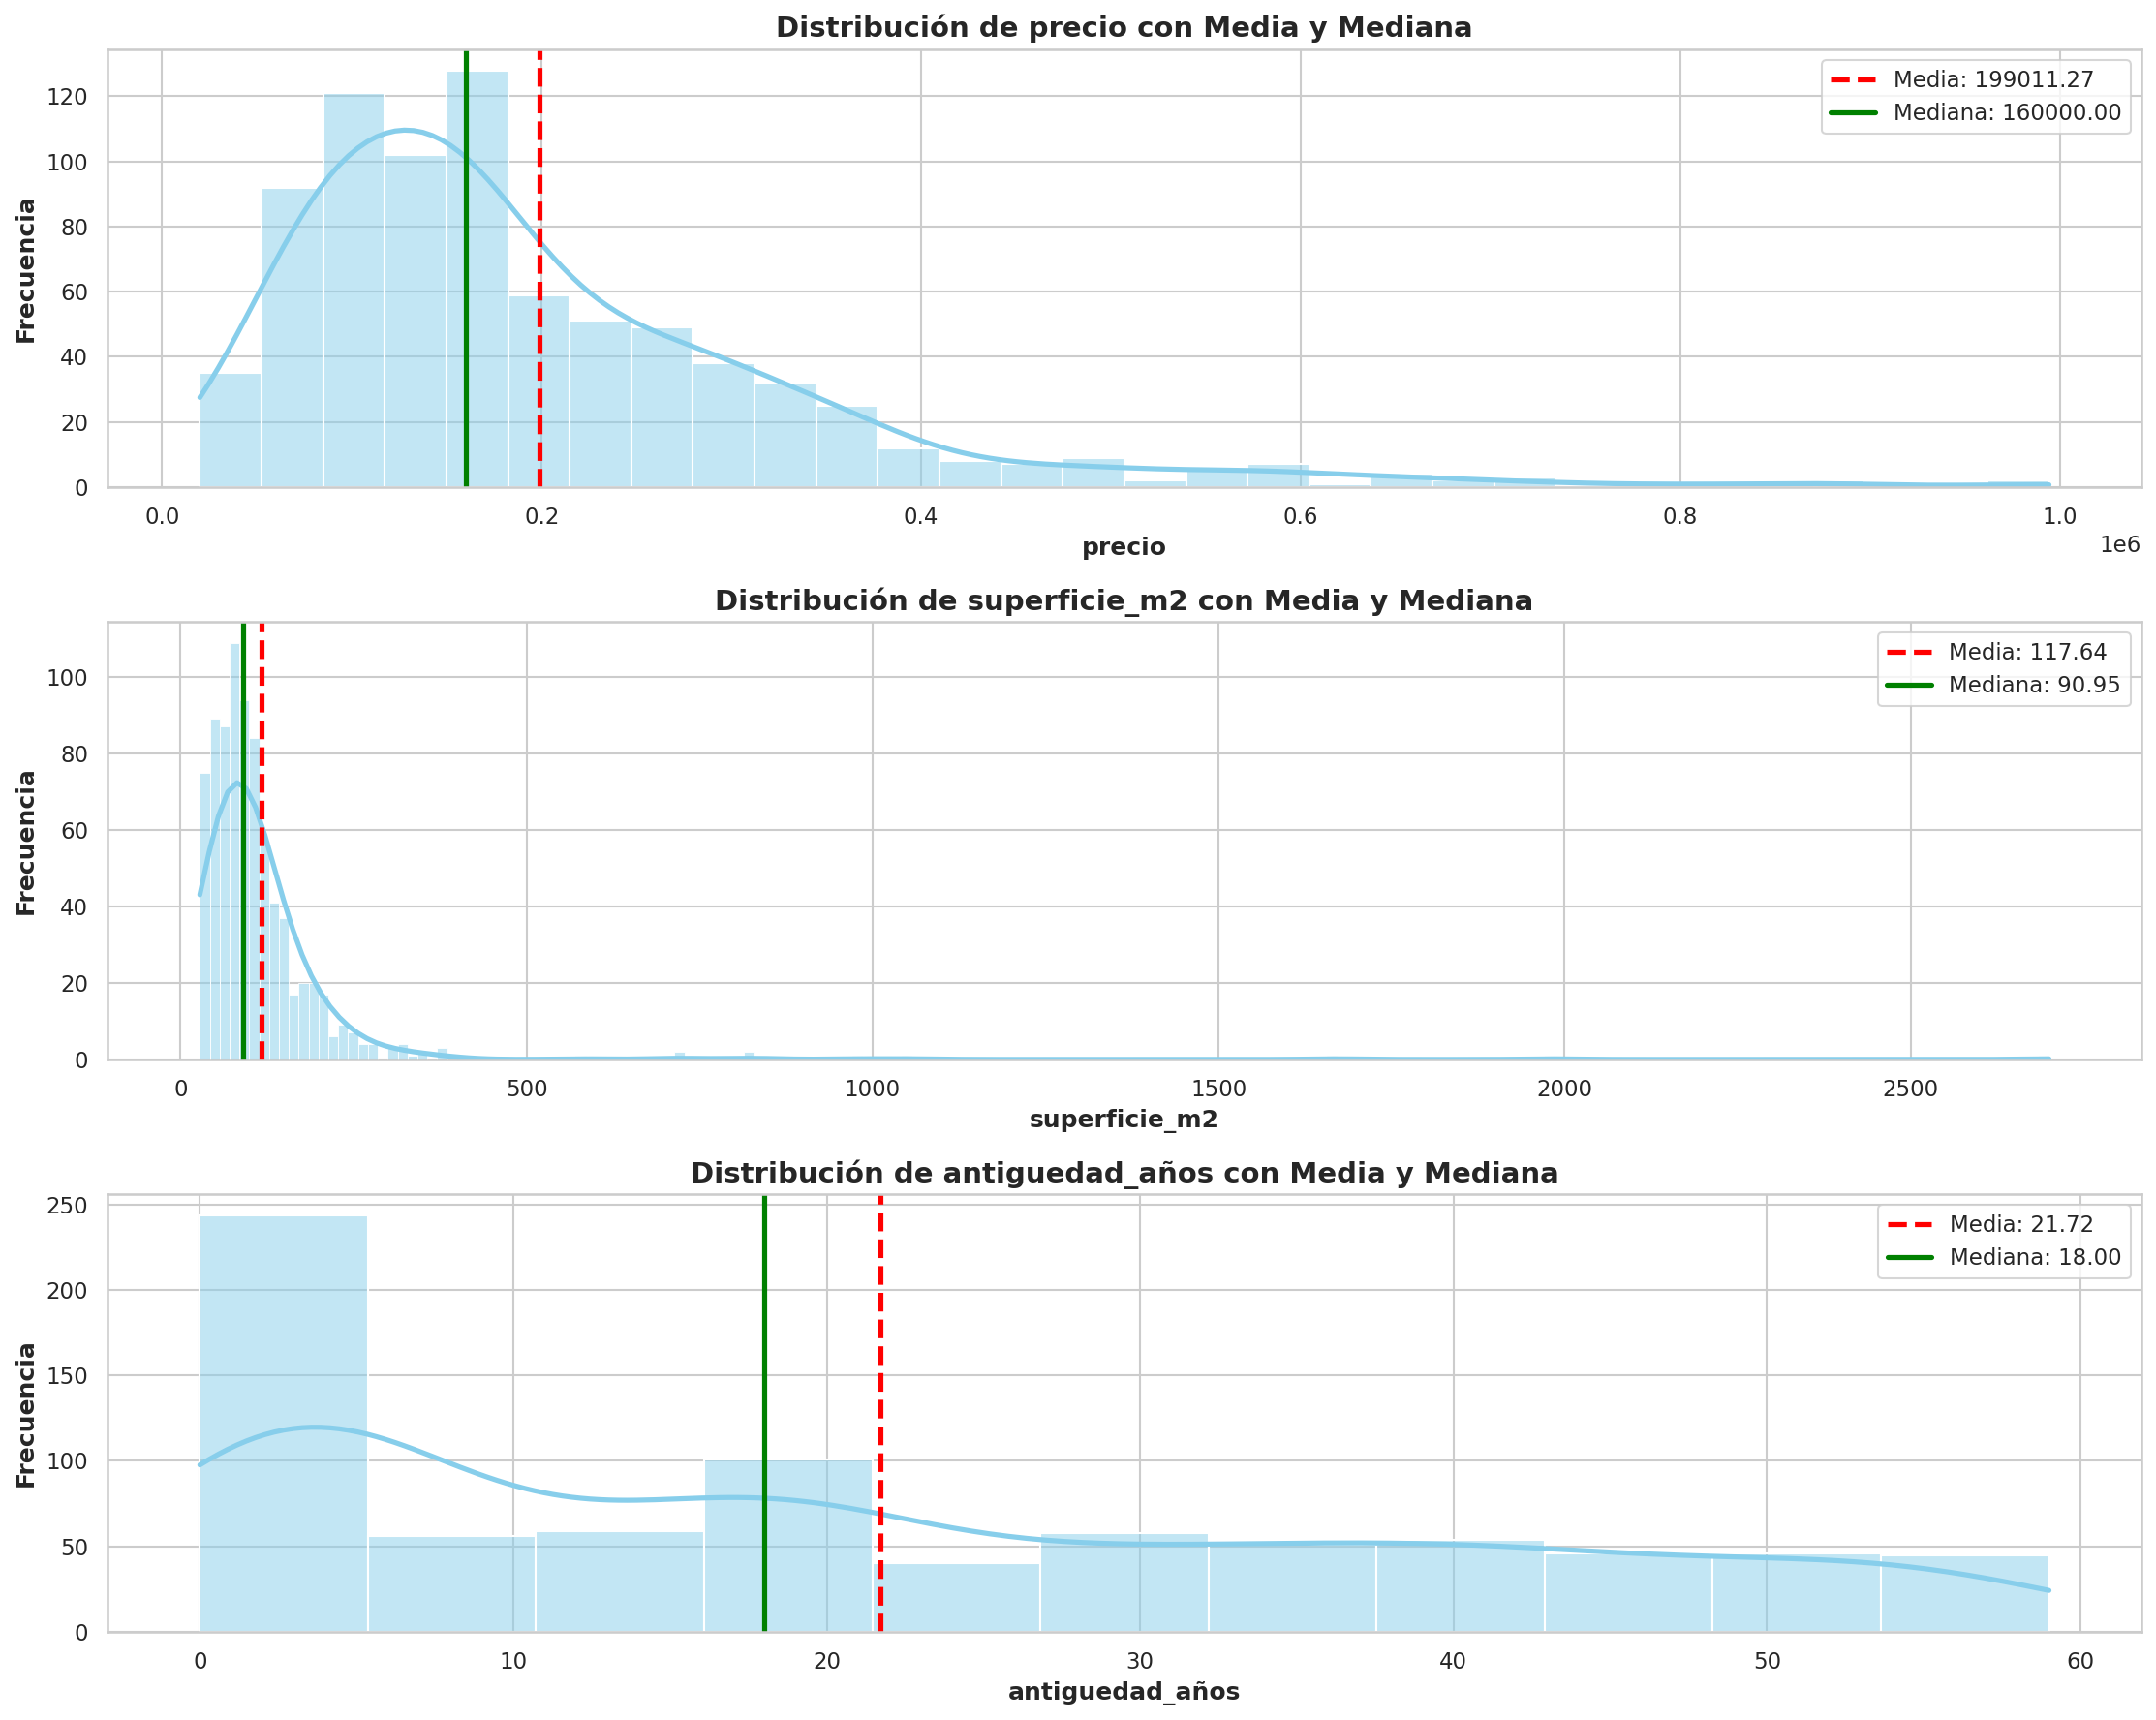

In [30]:
variables_to_plot = ['precio', 'superficie_m2', 'antiguedad_años']

plt.figure(figsize=(15, 12))

for i, var in enumerate(variables_to_plot):
    plt.subplot(3, 1, i + 1)
    sns.histplot(datasetPropiedades[var], kde=True, color='skyblue')

    # Calculate mean and median for the current variable
    mean_val = datasetPropiedades[var].mean()
    median_val = datasetPropiedades[var].median()

    # Add vertical lines for mean and median
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')

    plt.title(f'Distribución de {var} con Media y Mediana')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.legend()

plt.tight_layout()
plt.show()

Como podemos observar en los histogramas de `precio`, `superficie_m2` y `antiguedad_años`, la línea roja de la media y la línea verde de la mediana no coinciden. La media (roja) se encuentra a la derecha de la mediana (verde) en las tres variables, lo que indica una asimetría positiva o un sesgo hacia la derecha. Esto significa que la mayoría de los valores se concentran en el lado izquierdo de la distribución, pero hay algunos valores extremos altos que "empuja" la media hacia la derecha. Esto se alinea con las observaciones previas de que estas distribuciones no son simétricas y que la mediana es una medida de tendencia central más representativa que la media en estos casos.

### 1.3.3 Similitudes entre distribuciones

Hagamos un enfasis en la grafica anterior de la distribución del precio, y comparemosla con la siguiente grafica de una distribución logaritmica normal.

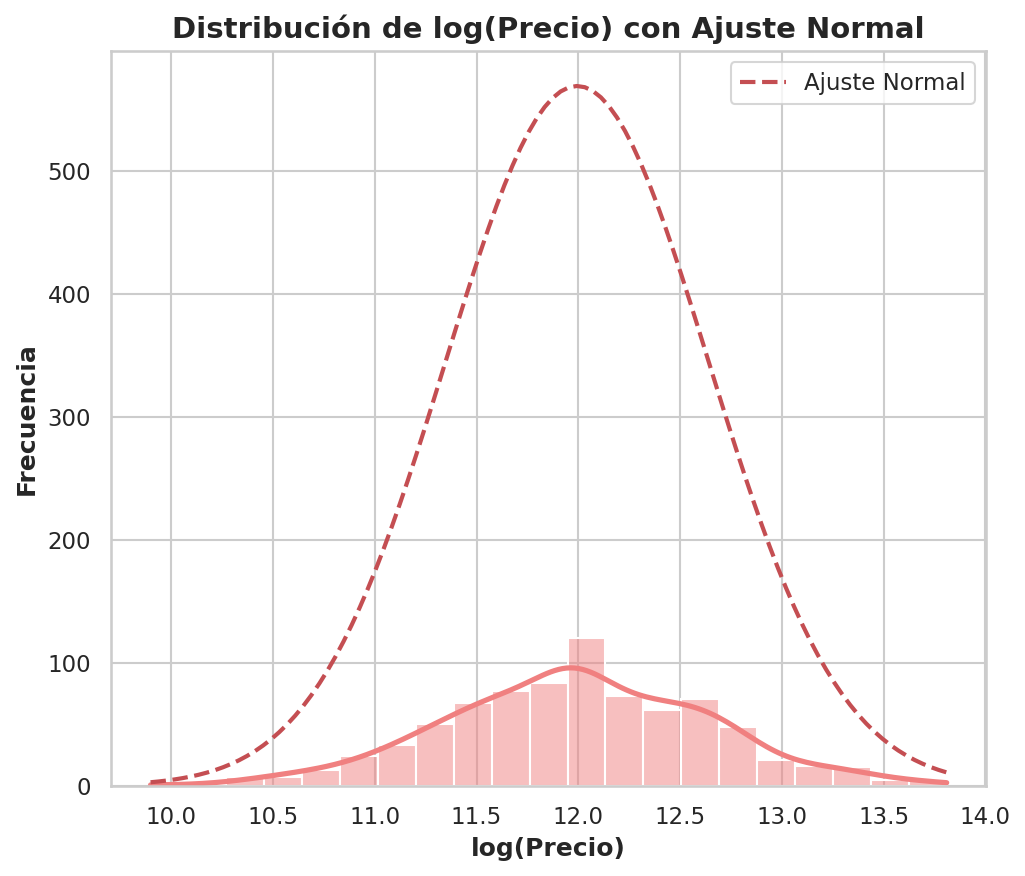

In [31]:
# Eliminar valores nulos de la columna 'precio' para el análisis
datos_precio = datasetPropiedades['precio'].dropna()

# Crear la figura y un subplot para la distribución de log(precio)
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

# Subplot: Distribución de log(precio) y ajuste a una distribución normal
log_precio = np.log(datos_precio)
sns.histplot(log_precio, kde=True, ax=ax, color='lightcoral')

# Ajustar una distribución normal a log_precio
mu, std = norm.fit(log_precio)
x_range = np.linspace(log_precio.min(), log_precio.max(), 100)
p_normal = norm.pdf(x_range, mu, std)

# Escalar la PDF para que se ajuste a la altura del histograma
max_hist_height = ax.patches[0].get_height() if ax.patches else 1
max_pdf_height = p_normal.max()
factor_de_escala = (max_hist_height / max_pdf_height) * (len(log_precio) * (log_precio.max() - log_precio.min()) / len(ax.get_xticks()))

ax.plot(x_range, p_normal * factor_de_escala, 'r--', linewidth=2, label='Ajuste Normal')

ax.set_title('Distribución de log(Precio) con Ajuste Normal')
ax.set_xlabel('log(Precio)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

Es una distribución con una visible asimetría positiva, y se asemeja a la distribución Log-Normal. Esto representa que hay más propiedades de precios bajos, pero existen algunas de lujo o de precios muy altos (valores atípicos) que elevan el promedio, por lo que en este caso la mediana es una medida de tendencia central mas representativa que la media aritmética.

---
#Parte vieja: >:(

---



---


###Visualización y detección de outliers

- Analizar la distribución de al menos tres variables numéricas utilizando histogramas y boxplots.

Las tres variables numéricas para su análisis serán `precio`, `superficie_m2` y `precio_m2`.

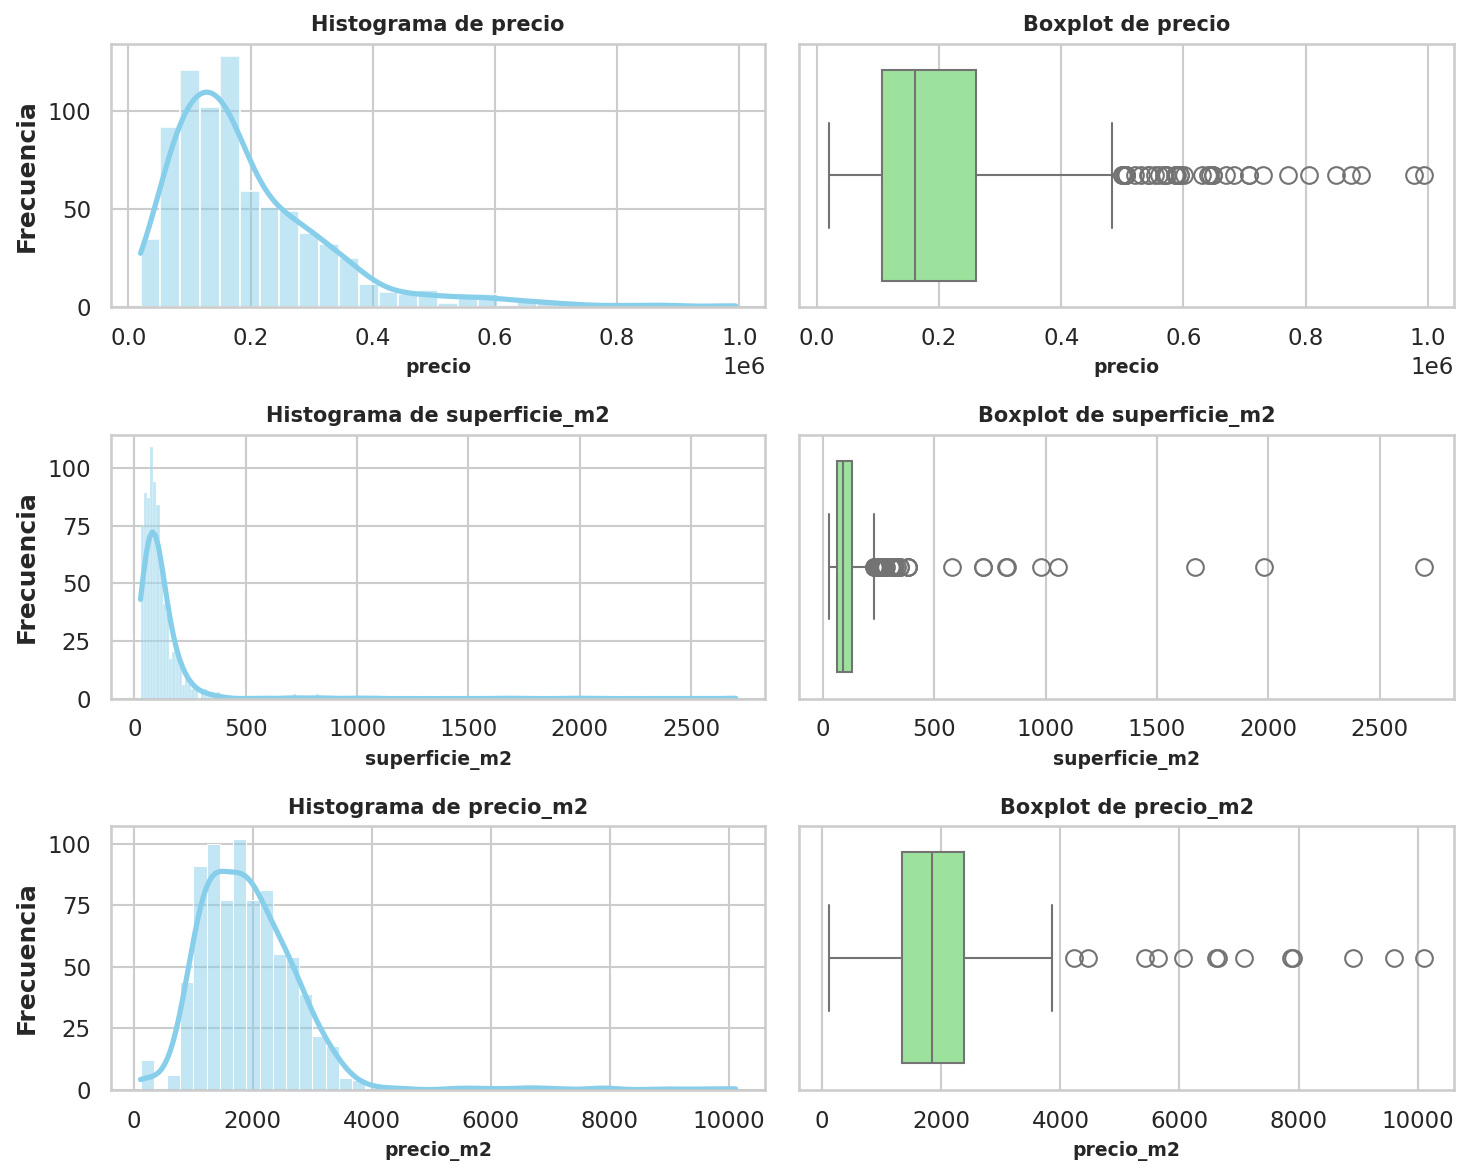

In [17]:
# carga de las 3 variables a analizar
variables = ['precio', 'superficie_m2', 'precio_m2']

# Se definen parametros para la creación de la visualización
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))

# bucle que itera entre gráfico por variable
for i, var in enumerate(variables):

    # gráfico izquierdo (Columna 0): Histograma
    sns.histplot(data=datasetPropiedades, x=var, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histograma de {var}', fontsize=10)
    axes[i, 0].set_xlabel(var, fontsize=9)

    # gráfico derecho (Columna 1): Boxplot
    sns.boxplot(data=datasetPropiedades, x=var, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot de {var}', fontsize=10)
    axes[i, 1].set_xlabel(var, fontsize=9)

    axes[i,0].set_ylabel('Frecuencia')

# se ajustamos el espaciado para evitar superposiciones
plt.tight_layout()

# impresión del gráfico final
plt.show()

Se puede evidenciar que ninguna de estas variables presenta una distribución normal simétrica. Los histogramas evidencian un fuerte sesgo hacia la derecha, lo que indica que la gran mayoría de las propiedades se concentran en valores bajos a medios, mientras que una minoría se extiende hacia valores extremadamente altos.

Por otro lado, analizando las visualizaciones de los boxplots, se detectan outliers evidentes en todas las variables analizadas.

No todos los outliers detectados estadísticamente deben eliminarse, ya que muchos representan la naturaleza real del dominio del problema.

Por ejemplo, en la variable `precio`, los valores atípicos superiores (cercanos o superior al millón) pueden ser perfectamente legíticmos. Representan propiedades de lujo o grandes terrenos en zonas de prestigio, por lo que eliminarlos significaría perder información valiosa del mercado.

Por el contrario, en la variable `superficie_m2`, el boxplot y el cálculo previo mostraron un valor extremo de mas de 2500 m2. En el contexto de viviendas urbanas estándar, esto es muy sospechoso y probablemente se deba a un error de tipeo (inconsistencia en la carga de datos). Este tipo de anomalías deben ser tratadas o eliminadas, ya que son ruido puro que afectarpa el rendimiento del modelo de IC.



---


### Relaciones entre variables:

¿Se identifica alguna variable en el dataset que sea el resultado de una operación matemática
entre otras columnas? De ser así, ¿esta variable aportaría información nueva al análisis? ¿Qué
impacto tendría incluirla en un análisis de correlación junto con sus variables de origen? Formular
una hipótesis al respecto y luego comprobar su validez mediante el cálculo o gráfico de correlación
correspondiente.

In [18]:
# Primeras 5 filas para verificar que los datos se leyeron correctamente
datasetPropiedades.head()

,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,648900.0,232.9,6,5.0,Palermo,2786.17
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59


Se puede observar que si se realiza el producto entre `superficie_m2` y `precio_m2` se obtine el `precio`. No aporta información nueva `precio_m2` al estar contenida en las otras 2 variables.

Si 2 variables poseen dependencia funcional directa o colinealidad, es decir el coeficientes de correlación es muy alto. El impacto que puede causar en modelos de IA predictivos, es que se confunda al estár recibir la misma información 2 veces y desestabiliza los calculos internos, esto afecta las métricas de éxito.
Entonces si se realiza la matríz de correlación las 3 variables tendrán alto coeficiente de correlación.


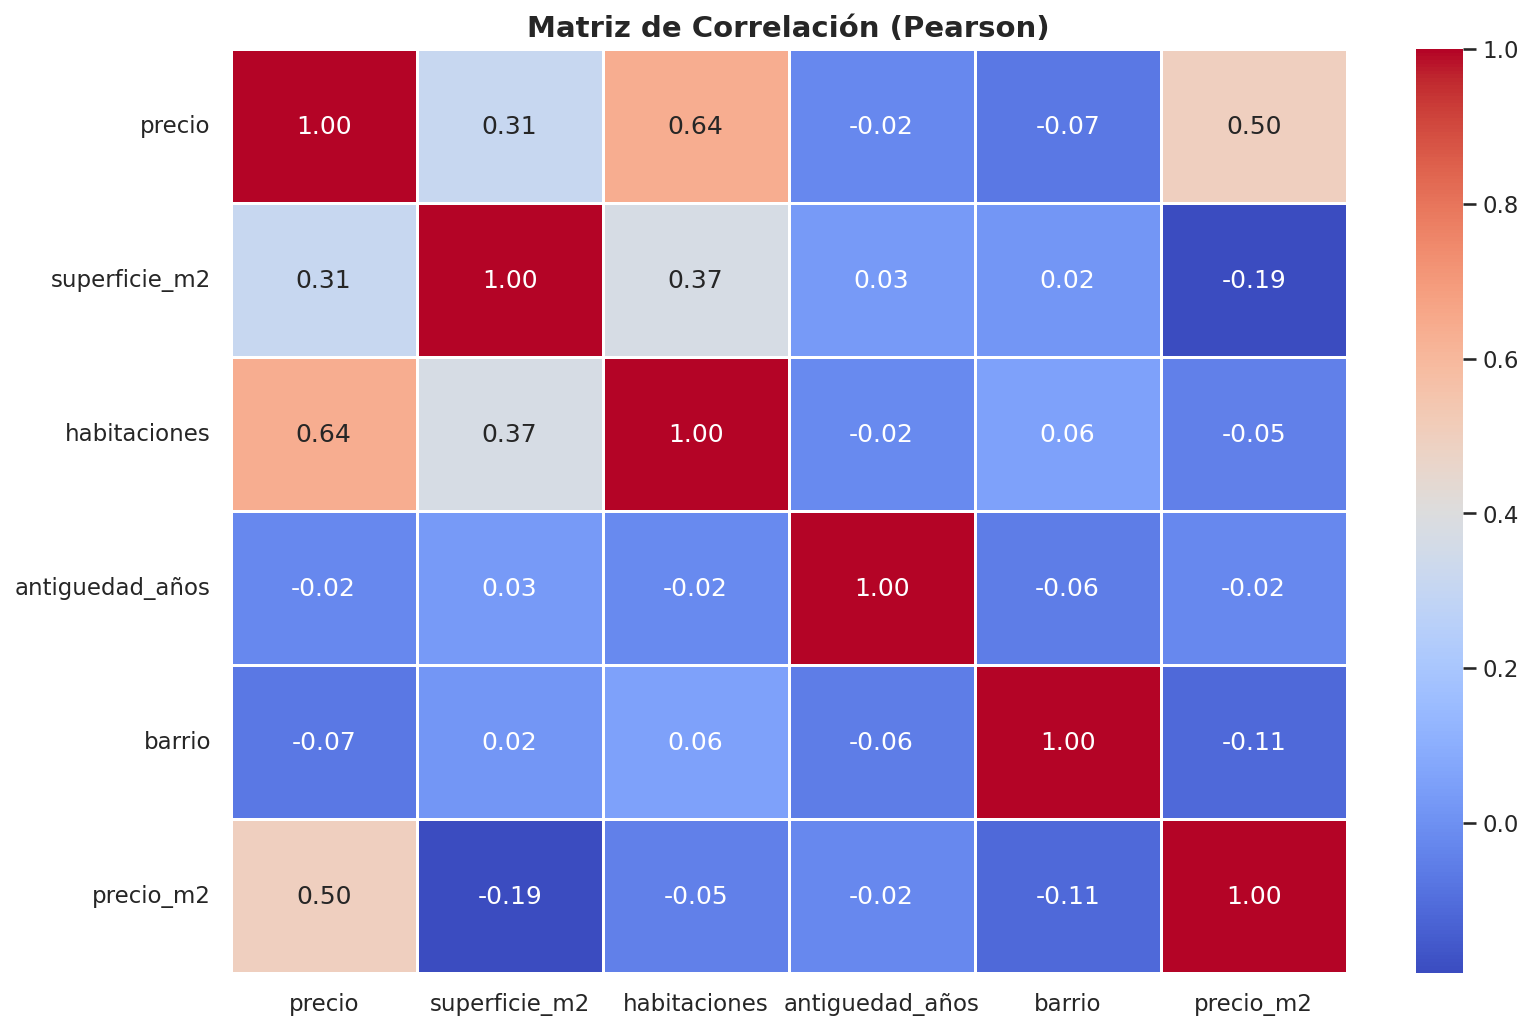

In [19]:
dataset_encoded = datasetPropiedades.copy()
le = LabelEncoder()

# Eliminamos la columna ID porque no tiene valor predictivo
dataset_encoded = dataset_encoded.drop(columns=['id'])

# Codificamos las variables categóricas, se pasa a numeros temporales debido a que aplicar la correlación estandar
# se trabaja con valores numéricos
for col in dataset_encoded.select_dtypes(include=['object', 'category', 'string']).columns:
    dataset_encoded[col] = le.fit_transform(dataset_encoded[col])

# Mostramos el mapa de calor con el coeficiente de Pearson
plt.figure(figsize=(12, 8))
sns.heatmap(dataset_encoded.corr(method='pearson'), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación (Pearson)')
plt.show()

Se puede observar que ese es el caso, si el modelo se encargase de predecir el valor de cada metro cuadrado del immueble en base a las demas variables del dataset lo mejor seria eliminar la columna del `precio_m2`.

¿Qué riesgo existiría al entrenar un algoritmo o modelo utilizando una variable de entrada que
tenga dependencia funcional directa con el valor que se quiere predecir (target)? ¿Cómo afectaría
a las métricas de éxito del modelo?  

El riesgo de entrenar un modelo con variables de entrada con dependencia directa a la variable salida (target) haria que empieze a memorizar, tomaria unicamente 2 variables de entrada en cuenta sin considerar las demás, debido a que poseen un vinculo matématico, esto se conoce como Target Leakage, porque se filtra la respuesta en dicho vinculo. Entonces el efecto de las metricas de éxito cuando comparamos con los resultados de entrenamiento puede llegar a ser perfecto, pero una vez que se le pruebe con nuevos datos el rendimiento se desploma.


¿Se observan diferencias de precio significativas entre barrios? Proponer una visualización que
permita comparar las distribuciones de precio por barrio de manera simultánea.

Lo lógico en la realidad es que los barrios mas seguros, y/o posean mas puntos de interes, sean los mas caros en cuanto al precio del immueble, entonces se puede comparar el precio promedio de cada barrio con un gráfico de barras como se muestra acontinuación.

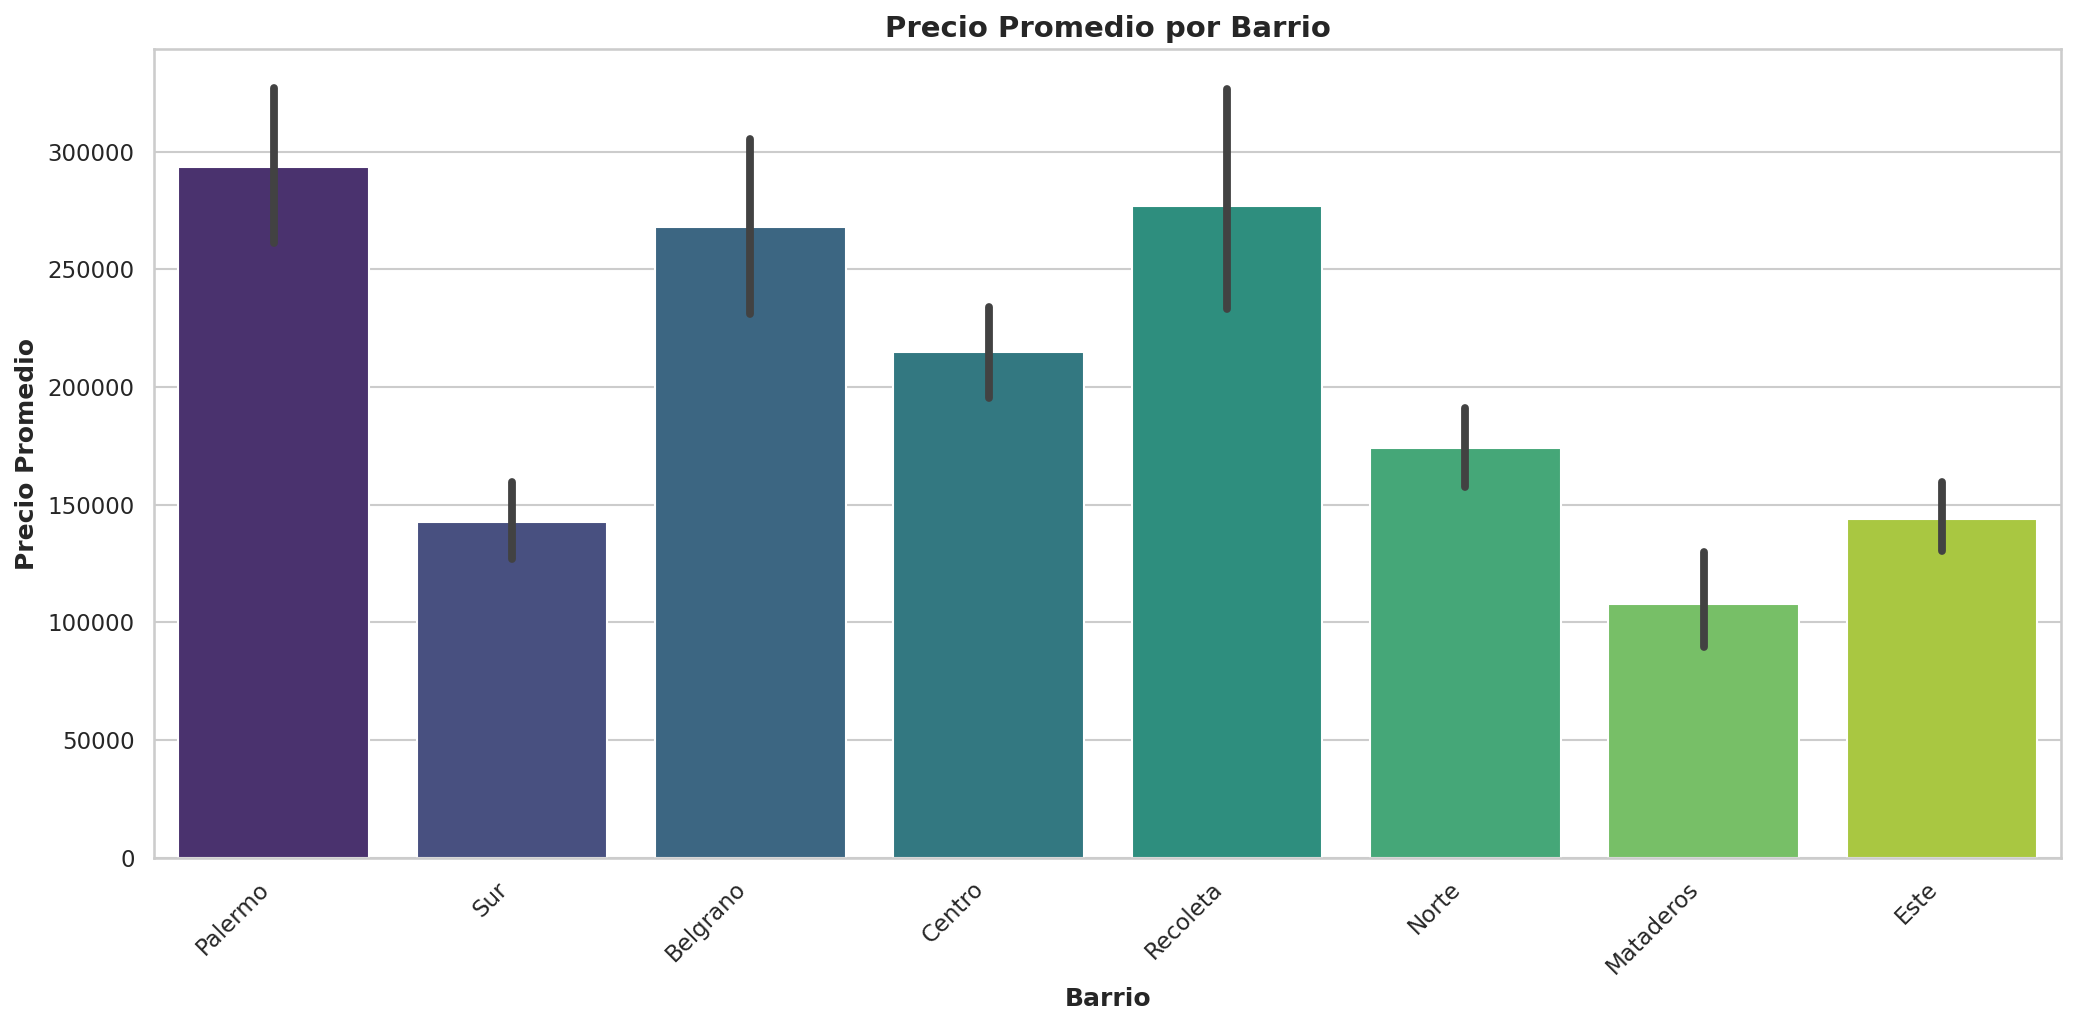

In [20]:
plt.figure(figsize=(14, 7))
sns.barplot(x='barrio', y='precio', data=datasetPropiedades, palette='viridis')
plt.title('Precio Promedio por Barrio')
plt.xlabel('Barrio')
plt.ylabel('Precio Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Podemos observar que Palermo es el barrio con los precios promedios mas altos, lo cual tiene sentido según lo anteriormente explicado, y mataderos posee los precios mas bajos en promedio.

---

##Ejercicio 2 - Exploración comparativa
Para este ejercicio se incorpora un segundo dataset, correspondiente al historial de clientes de una empresa de telecomunicaciones con información sobre cancelación del servicio (churn). El dataset incluye variables como antigüedad del cliente, tipo de contrato, monto mensual facturado, cantidad de productos contratados y una variable binaria que indica si el cliente abandonó el servicio (churn: 0 = permanece, 1 = se fue). En la Tabla 2, se presenta un fragmento representativo.


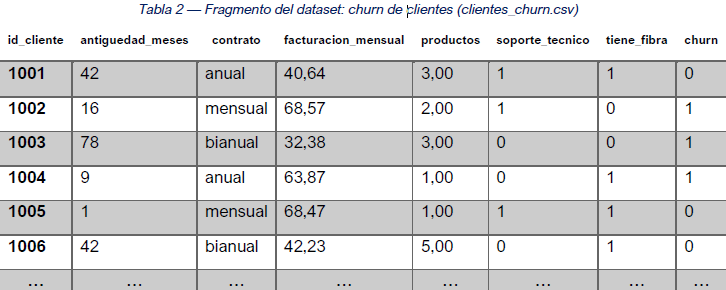

El objetivo es comparar ambos datasets desde el punto de vista exploratorio, desarrollando criterio sobre las particularidades de cada uno. Responder como mínimo las siguientes consignas:

---
###Comparación general

- ¿Cuál de los dos datasets parece más limpio en términos de calidad de datos? ¿Por qué?

Para hacer una comparacion, primero debemos analizar los datos del dataset 'churn de clientes'.

In [21]:
# Primeras 5 filas para verificar que los datos se leyeron correctamente
datasetChurn.head()

,id_cliente,antiguedad_meses,contrato,facturacion_mensual,productos,soporte_tecnico,tiene_fibra,churn
0,1001,42,anual,40.64,3.0,1,1,0
1,1002,16,mensual,68.57,2.0,1,0,1
2,1003,78,bianual,32.38,3.0,0,0,1
3,1004,9,anual,63.87,1.0,0,1,1
4,1005,1,mensual,68.47,1.0,1,1,0


In [22]:
# Resumen de los tipos de datos y recuento de valores no nulos
datasetChurn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_cliente           1200 non-null   int64  
 1   antiguedad_meses     1200 non-null   int64  
 2   contrato             1200 non-null   object 
 3   facturacion_mensual  1164 non-null   float64
 4   productos            1140 non-null   float64
 5   soporte_tecnico      1200 non-null   int64  
 6   tiene_fibra          1200 non-null   int64  
 7   churn                1200 non-null   int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 75.1+ KB


In [23]:
# Contabilizar valores nulos por columna
datasetChurn.isna().sum()

,0
id_cliente,0
antiguedad_meses,0
contrato,0
facturacion_mensual,36
productos,60
soporte_tecnico,0
tiene_fibra,0
churn,0


In [24]:
valores_nulos_propiedades = datasetPropiedades.isna().sum()
valores_nulos_churn = datasetChurn.isna().sum()

# Calculamos el porcentaje de valores nulos
porcentaje_valores_nulos_propiedades = (valores_nulos_propiedades / len(datasetPropiedades))
porcentaje_valores_nulos_churn = (valores_nulos_churn / len(datasetChurn))

comparacion_datos_nulos = pd.DataFrame({
    'DatasetPropiedades': porcentaje_valores_nulos_propiedades,
    'DatasetChurn': porcentaje_valores_nulos_churn
})

# Display only rows with at least one missing value in either dataset
comparacion_datos_nulos = comparacion_datos_nulos[(comparacion_datos_nulos['DatasetPropiedades'] > 0) | \
                                                  (comparacion_datos_nulos['DatasetChurn'] > 0)]

print("\nPorcentaje de valores Nulos:")
display(comparacion_datos_nulos.fillna(0))


Porcentaje de valores Nulos:


,DatasetPropiedades,DatasetChurn
facturacion_mensual,0.0,0.03
productos,0.0,0.05


In [25]:
numerical_cols = datasetChurn.select_dtypes(include=['number']).columns

# Calcular la media y la mediana para cada columna numérica
valores_media = datasetChurn[numerical_cols].mean()
valores_mediana = datasetChurn[numerical_cols].median()

# Calcular la diferencia absoluta entre la media y la mediana
diferencia = (valores_media - valores_mediana).abs()

# Calcular la diferencia porcentual
diferencia_porcentual = (diferencia / valores_mediana) * 100

# Crear un DataFrame para mostrar los resultados
diferencias_df = pd.DataFrame({
    'Media': valores_media,
    'Mediana': valores_mediana,
    'Diferencia Absoluta (Media - Mediana)': diferencia,
    'Diferencia Porcentual (%)': diferencia_porcentual
}).sort_values(by='Diferencia Porcentual (%)', ascending=False)

display(diferencias_df)

,Media,Mediana,Diferencia Absoluta (Media - Mediana),Diferencia Porcentual (%)
churn,0.326667,0.0,0.326667,inf
soporte_tecnico,0.559167,1.0,0.440833,44.083333
tiene_fibra,0.590000,1.0,0.410000,41.000000
antiguedad_meses,30.383333,24.0,6.383333,26.597222
productos,2.472807,2.0,0.472807,23.640351
facturacion_mensual,63.840275,62.4,1.440275,2.308133
id_cliente,1600.500000,1600.5,0.000000,0.000000


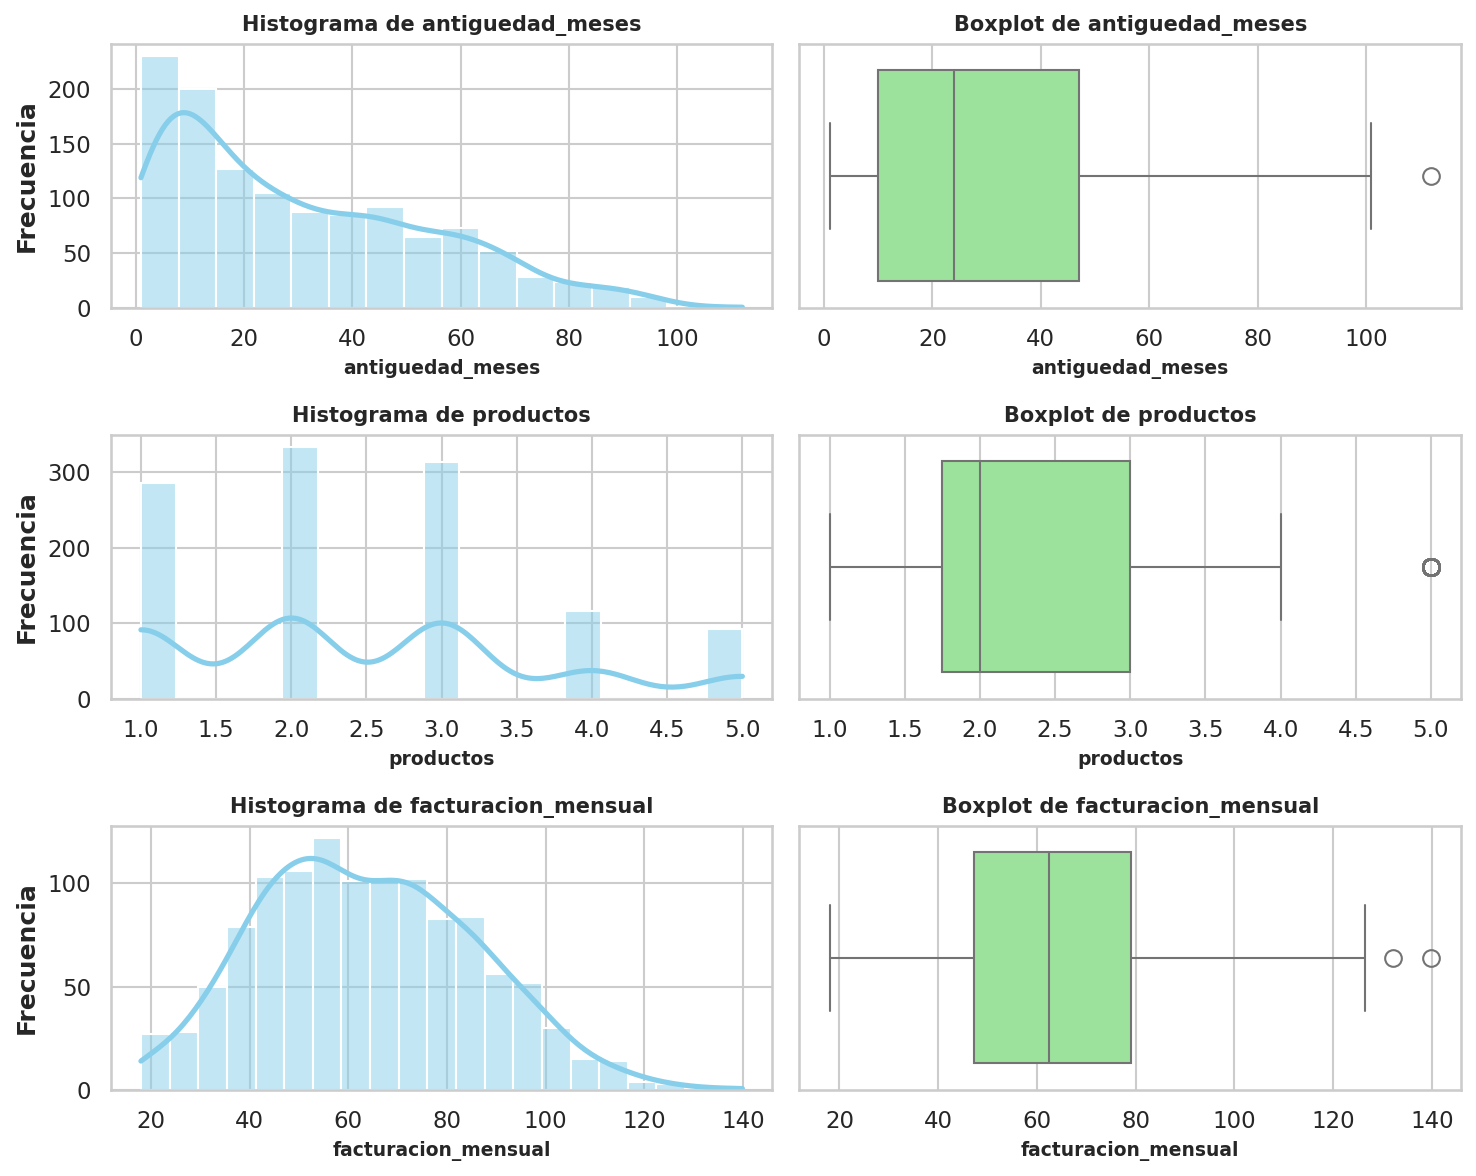

In [26]:
# carga de las 3 variables a analizar
variables = ['antiguedad_meses', 'productos', 'facturacion_mensual']

# Se definen parametros para la creación de la visualización
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))

# bucle que itera entre gráfico por variable
for i, var in enumerate(variables):

    # gráfico izquierdo (Columna 0): Histograma
    sns.histplot(data=datasetChurn, x=var, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histograma de {var}', fontsize=10)
    axes[i, 0].set_xlabel(var, fontsize=9)

    # gráfico derecho (Columna 1): Boxplot
    sns.boxplot(data=datasetChurn, x=var, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot de {var}', fontsize=10)
    axes[i, 1].set_xlabel(var, fontsize=9)

    axes[i,0].set_ylabel('Frecuencia')

# se ajustamos el espaciado para evitar superposiciones
plt.tight_layout()

# impresión del gráfico final
plt.show()

Como podemos observar, en el caso de `datasetChurn` tenemos menor porcentaje de valores faltantes y menos *outliers*, ademas de tener mas entradas de datos que en el caso de `datasetPropiedades`. Aparentemente, podria decirse que el dataset de churn esta mas limpio.

- ¿Cuál presenta mayor complejidad desde el punto de vista exploratorio? ¿A qué atribuyen esa complejidad?

Basandonos en los datos recopilados anteriormente, podemos decir que el dataset de propiedades tiene una mayor complejidad exploratoria, ya que posee una mayor cantidad de datos o espacios vacios que necesitan atenderse para el correcto analisis.

---
###Reflexión orientada al preprocesamiento

- ¿Qué transformaciones o preprocesamientos serían necesarios antes de alimentar un modelo con estos datos? ¿En qué variables se utilizaría normalización/estandarización? ¿Qué variables deberían pasar por un proceso de codificación (encoding)? ¿Qué método de encoding aplicarían? ¿Hay un orden jerárquico en estas variables que deba preservarse?

Inicialmente deberiamos quitar la *feature* `id_cliente`, ya que solo aporta ruido al analisis.

Luego se deberia resolver que hacer con los espacios nulos y *outliers* de `facturacion_mensual` y `productos`. En el caso de la facturacion mensual, se puede utilizar la mediana para completar los espacios vacios y verificar si los valores atipicos son correctos o errores de tipeo.

In [27]:
clientes_con_facturacion_alta = datasetChurn[datasetChurn['facturacion_mensual'] > 120]
print(f"Cantidad de clientes con facturación mensual mayor a 120: {len(clientes_con_facturacion_alta)}")

Cantidad de clientes con facturación mensual mayor a 120: 7


Otra solucion seria simplemente eliminar los datos con un valor de facturacion mensual por sobre 120, principalmente porque son pocos datos los que perderiamos.

Para la *feature* productos podriamos simplemente usar la moda para completar los valores nulos.

In [28]:
clientes_con_5_productos = len(datasetChurn[datasetChurn['productos'] == 5])
print(f"Cantidad de clientes con 5 productos: {clientes_con_5_productos} (un {(clientes_con_5_productos/1200)*100}% de los clientes)")

Cantidad de clientes con 5 productos: 93 (un 7.75% de los clientes)


Y el valor atipico de 5 productos se repite demasiadas veces para ser un error de tipeo, lo mas probable es que existan varios usuarios que necesiten pagar 5 productos simultaneamente.

###



---
parte del colab axel

---

### Carga y Exploración Inicial

Primero, cargamos los datos y damos un "vistazo" rápido a su estructura. Usamos `pandas`, la librería por excelencia para el manejo de datos tabulares en Python.

In [29]:
# Resumen de los tipos de datos y recuento de valores no nulos
dataset.info()

NameError: name 'dataset' is not defined

Observamos que algunas columnas son de tipo `object` (strings categóricos), otras `int64` (enteros) y `float64` (decimales).
¡Tenemos datos faltantes!
precio 32


In [ ]:
# Descriptores estadísticos básicos para las columnas numéricas
dataset.describe()

### 3. Tratamiento de Datos Faltantes (*Missing Values*)

Los modelos de ML matemáticos no saben cómo lidiar con un valor vacío (`NaN` o `Null`). Debemos identificarlos y tomar decisiones informadas sobre qué hacer con ellos.

In [ ]:
# Contabilizar valores nulos por columna
dataset.isna().sum()

Según el contexto de nuestro problema (ver tarjeta del *dataset* en [*ACV Dataset*](https://github.com/AxelSkrauba/applied-ai-engineering/blob/main/datasets/acv/README.md)), en la variable `estado_fumador`, la categoría "desconocido" se utilizó para las entradas donde no había información. **Esto es funcionalmente un dato faltante** disfrazado de categoría. Vamos a exponerlo como tal para tratarlo correctamente.

In [ ]:
# Reemplazamos "desconocido" por el valor nulo estándar de numpy (np.nan)
dataset['estado_fumador'] = dataset['estado_fumador'].replace('desconocido', np.nan)

# Calculamos el porcentaje de valores perdidos
miss_val_pct = dataset.isnull().sum() / len(dataset) * 100
print("Porcentaje de valores faltantes:")
print(miss_val_pct[miss_val_pct > 0].apply(lambda x: f"{x:.2f}%"))

Para variables numéricas con bajo porcentaje de faltantes (como el `imc`, ~3.9%), una práctica común es **imputar** (rellenar) esos huecos con la **mediana** de la distribución, ya que es más robusta a *outliers* que la media.

Para variables categóricas con un alto porcentaje (como `estado_fumador`, ~30%), la decisión es más difícil. Podríamos imputar con la moda (el más frecuente), pero estaríamos sesgando mucho los datos. En este ejemplo didáctico, optaremos por **eliminar** las filas que no tengan esta información.

*Nota: En un escenario real estricto, descartar el 30% de los datos duele (en sentido figurado, por las dudas...). Se podrían usar técnicas avanzadas de imputación (ej: predecir el estado fumador basado en la edad y enfermedades).*

In [ ]:
# 1. Imputación de IMC con la mediana
mediana_imc = dataset['imc'].median()
dataset['imc'] = dataset['imc'].fillna(mediana_imc)

# 2. Descarte de filas con 'estado_fumador' nulo
dataset = dataset.dropna(subset=['estado_fumador'])

print(f"Filas restantes después de la limpieza: {len(dataset)}")
print(f"Valores nulos restantes:\n{dataset.isna().sum().sum()}")

### 4. Análisis de Distribuciones y Desbalance

Vamos a explorar cómo se distribuyen nuestras variables categóricas, prestando especial atención a nuestra variable objetivo (`apoplejia`).

In [ ]:
# Gráfico de pastel para el estado laboral
plt.figure(figsize=(6, 6))
dataset['tipo_trabajo'].value_counts().plot.pie(autopct='%1.1f%%', cmap='Set3', ylabel='')
plt.title('Distribución por Tipo de Trabajo')
plt.show()

In [ ]:
# Verificamos el balance de nuestra variable a predecir
plt.figure(figsize=(6, 4))
sns.countplot(data=dataset, x='apoplejia', palette='pastel')
plt.title('Distribución de Casos de ACV (0=No, 1=Sí)')
plt.ylabel('Cantidad de Pacientes')
plt.show()

casos_positivos = (dataset['apoplejia'] == 1).sum()
pct_positivos = casos_positivos / len(dataset) * 100
print(f"Casos positivos de ACV: {casos_positivos} ({pct_positivos:.2f}%)")

**¡Alerta de Desbalance!** ⚠️

Notamos que los casos positivos (ACV) representan una fracción mínima del *dataset* (apenas un ~5.6%). Este es un escenario muy común en salud, detección de fraudes y mantenimiento predictivo.
Si entrenamos un modelo así, probablemente aprenderá a predecir siempre "0" y logrará un 94% de precisión (Accuracy), siendo completamente inútil. En fases posteriores (Modelado) abordaremos técnicas como el submuestreo o SMOTE para lidiar con esto.

### 5. Detección de Valores Atípicos (*Outliers*)

Los *outliers* son valores que se desvían drásticamente del resto de la distribución. Pueden ser errores de carga de datos o anomalías reales muy raras. Usamos diagramas de caja (*Boxplots*) para detectarlos visualmente en las variables continuas.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=dataset['edad'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad')

sns.boxplot(y=dataset['nivel_glucosa'], ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución de Nivel de Glucosa')

sns.boxplot(y=dataset['imc'], ax=axes[2], color='salmon')
axes[2].set_title('Distribución de IMC')

plt.tight_layout()
plt.show()

Observamos que no hay *outliers* evidentes en `edad`, pero sí muchos valores extremos altos en `nivel_glucosa` e `imc`.
*   Un `imc` cercano a 80-90 es biológicamente extremo (aunque posible en obesidad mórbida severa), pero podría ser un error tipográfico.
*   Un nivel de glucosa superior a 200 indica diabetes severa, lo cual es real y un fuerte factor de riesgo para ACV, por lo que **no deberíamos eliminarlos ciegamente**.

Para este ejercicio, filtramos (a modo de ejemplo) solo los valores de `imc` extremadamente dudosos (> 60).

In [ ]:
# Descarte condicional
dataset = dataset[dataset['imc'] <= 60]
print(f"Filas tras eliminar outliers de IMC: {len(dataset)}")

### 6. Relaciones entre Variables (Correlación)

Para entender cómo se relacionan las variables entre sí, podemos usar una matriz de correlación. Sin embargo, matemáticamente la correlación estándar (Pearson) se aplica a valores numéricos. Por lo tanto, debemos transformar nuestras variables categóricas (*strings*) a números temporales.

#### Tipos de Correlación (Mini Teoría)
- **Pearson**: Mide relaciones lineales. Ideal para distribuciones normales continuas.
- **Spearman**: Basado en rangos. Útil para relaciones monótonas (si uno sube, el otro también, pero no necesariamente en línea recta) o si hay muchos outliers.
- **Kendall**: Similar a Spearman, pero más robusto cuando el dataset es pequeño o hay muchos "empates" de valores.

Vamos a codificar rápidamente las categóricas usando `LabelEncoder` de `scikit-learn`.

In [ ]:
from sklearn.preprocessing import LabelEncoder

dataset_encoded = dataset.copy()
le = LabelEncoder()

# Eliminamos la columna ID porque no tiene valor predictivo
dataset_encoded = dataset_encoded.drop(columns=['id'])

# Codificamos las variables categóricas
for col in dataset_encoded.select_dtypes(include=['object', 'category', 'string']).columns:
    dataset_encoded[col] = le.fit_transform(dataset_encoded[col])

# Mostramos el mapa de calor con el coeficiente de Pearson
plt.figure(figsize=(12, 8))
sns.heatmap(dataset_encoded.corr(method='pearson'), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación (Pearson)')
plt.show()

En el mapa de calor, buscamos valores cercanos a 1 (correlación positiva fuerte) o -1 (correlación negativa fuerte).
*   Observamos una alta correlación (0.68) entre la `edad` y `casado_alguna_vez`. ¡Tiene todo el sentido lógico!
*   La variable objetivo `apoplejia` tiene sus mayores correlaciones positivas con la `edad` (0.24), el `nivel_glucosa` (0.13) y la presencia de `hipertension` (0.14) o `enfermedad_corazon` (0.14). Esto nos confirma que estas variables serán predictoras importantes para nuestros futuros modelos.

**NOTA**: para entender mejor las correlaciones, explorar el notebook [Análisis de Correlación y Asociación](03_analisis_correlacion_y_asociacion.ipynb)

## Resultados y Discusión

A partir de este EDA básico, hemos concluido que:
1. Nuestro *dataset* sufre de un **fuerte desbalance de clases**, requiriendo atención especial en la fase de modelado.
2. Identificamos y tratamos datos faltantes de manera fundamentada (imputación por mediana para numéricos, descarte para categóricos).
3. Confirmamos mediante correlaciones que factores biológicos como la edad, la glucosa y condiciones cardíacas preexistentes están ligados a la probabilidad de un ACV en nuestros datos.
4. Identificamos que variables como el `id` no aportan información y solo introducen ruido.

## Conexiones y Próximos Pasos
- ➡️ **Siguiente:** [Feature Engineering y Limpieza de Datos](02_feature_engineering_y_limpieza.ipynb).
- 🔄 **Relacionado:** Con el dataset limpio, estamos listos para entender qué hacen los modelos con esto [Introducción a la Clasificación](../03_machine_learning/01_introduccion_clasificacion.ipynb).

## Referencias
1. Dataset ACV: Healthcare Dataset Stroke Data (Kaggle).
2. [Documentación Oficial de Pandas](https://pandas.pydata.org/docs/)
3. [Documentación de Seaborn para Visualización Estadística](https://seaborn.pydata.org/)

---
## Entorno de Ejecución

In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)